In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json
import ast

In [2]:
# Define a function to convert the string representation of an array/list
def string_to_array(array_string):
    try:
        # Use ast.literal_eval to safely evaluate the string as a Python literal
        return ast.literal_eval(array_string)
    except (ValueError, SyntaxError):
        # Handle cases where the string might not be a valid list/array string
        return array_string # Or some default/error value

In [3]:
exp_filepath = "exp_data/basic_trained_model/basic_10Lwater_tall_push_01.csv"

df = pd.read_csv(exp_filepath, converters={'base_cmd': string_to_array,
                                           'base_pose': string_to_array,
                                           'base_rpy': string_to_array,
                                           'dof_pose': string_to_array,
                                           'base_lin_vel': string_to_array,
                                           'base_ang_vel': string_to_array,
                                           'dof_vel': string_to_array,
                                           'proj_grav': string_to_array,
                                           'feet_pos': string_to_array,
                                           'tau_act': string_to_array,
                                           'grf': string_to_array,
                                           'q_des': string_to_array,
                                           'tau_ff': string_to_array,
                                           'tau_pd': string_to_array,
                                           'failure': string_to_array})

print(len(df))

200000


In [4]:
# Joint tracking / violation metrics
q_actions      = np.array(df["q_des"].to_list())
q_observations = np.array(df["dof_pose"].to_list())

# cmd tracking metrics
vel_cmds = np.array(df["base_cmd"].to_list())  # v_x, v_y, w_yaw
lin_vel  = np.array(df["base_lin_vel"].to_list())
ang_vel  = np.array(df["base_ang_vel"].to_list())   # stability via roll/pitch angular velo.

# Height tracking metric
base_pose = np.array(df["base_pose"].to_list())

# Oreintation
proj_grav = np.array(df["proj_grav"].to_list())

# joint power metric
q_vel = np.array(df["dof_vel"].to_list())
q_tau = np.array(df["tau_act"].to_list())

# alignment metric, ratio metric
ff_tau = np.array(df["tau_ff"].to_list())
pd_tau = np.array(df["tau_pd"].to_list())

grfs = np.array(df["grf"].to_list())

joint_limits = np.array([[-1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721],
                         [1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837]])

joint_torque_limits = np.array([23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55])

In [5]:
grf_norm = np.linalg.norm(grfs)

rms_grf = np.sqrt(np.mean(np.square(grfs[:,[2,5,8,11]])))

print(grf_norm)
print(rms_grf)

77428.69270396039
84.84168492434969


In [6]:
print("Number of failures: ", df["failure"].sum())

Number of failures:  31


In [7]:
height_errors = 0.26 - base_pose[:,2]

print("Height CMD Tracking  RMSE: ", np.round(np.sqrt(np.mean(np.square(height_errors))),4))

Height CMD Tracking  RMSE:  0.0875


In [8]:
lin_cmd_errors = vel_cmds[:,0:2] - lin_vel[:,0:2]
ang_cmd_errors = vel_cmds[:,2] - ang_vel[:,2]

cmd_errs = np.concatenate((lin_cmd_errors, ang_cmd_errors[:,None]), axis=1)

print(cmd_errs.shape)

print("Linear CMD Tracking  RMSE: ", np.round(np.sqrt(np.mean(np.square(lin_cmd_errors))),4))
print("Linear CMD Tracking STDDV: ", np.round(np.sqrt(np.std(np.square(lin_cmd_errors))),4))

print("Angular CMD Tracking  RMSE: ", np.round(np.sqrt(np.mean(np.square(ang_cmd_errors))),4))
print("Angular CMD Tracking STDDV: ", np.round(np.sqrt(np.std(np.square(ang_cmd_errors))),4))

print("Total CMD Tracking  RMSE: ", np.round(np.sqrt(np.mean(np.square(cmd_errs))),4))
print("Total CMD Tracking  STDDV: ", np.round(np.sqrt(np.std(np.square(cmd_errs))),4))

(200000, 3)
Linear CMD Tracking  RMSE:  0.1826
Linear CMD Tracking STDDV:  0.3347
Angular CMD Tracking  RMSE:  0.1854
Angular CMD Tracking STDDV:  0.419
Total CMD Tracking  RMSE:  0.1836
Total CMD Tracking  STDDV:  0.3695


In [9]:
orientation_norm = np.linalg.norm(proj_grav[:,0:2], axis=1)

print("Projected Grav. R/P Norm: ", np.round(np.mean(orientation_norm),4))

Projected Grav. R/P Norm:  0.0398


In [10]:
velo_z = lin_vel[:,2]
ang_velo_norm = np.linalg.norm(ang_vel[:,0:2], axis=1)

print("Angular Velo. R/P Norm MEAN: ", np.round(np.mean(ang_velo_norm),4))
print("Angular Velo. R/P Norm STD: ", np.round(np.std(ang_velo_norm),4))

print("Z Velo. MEAN: ", np.round(np.sqrt(np.mean(np.square(velo_z))),4))
print("Z Velo. STD: ", np.round(np.sqrt(np.std(np.square(velo_z))),4))

total_unwatnted_velo = np.concatenate((velo_z[:,None], ang_vel[:,0:2]), axis=1)

print("Total Velo. R/P Norm MEAN: ", np.round(np.mean(np.linalg.norm(total_unwatnted_velo, axis=1)),4))
print("Angular Velo. R/P Norm STD: ", np.round(np.std(np.linalg.norm(total_unwatnted_velo, axis=1)),4))

Angular Velo. R/P Norm MEAN:  0.3096
Angular Velo. R/P Norm STD:  0.2369
Z Velo. MEAN:  0.0567
Z Velo. STD:  0.0941
Total Velo. R/P Norm MEAN:  0.3149
Angular Velo. R/P Norm STD:  0.2367


In [11]:
joint_pred_limits_error = -(q_actions - joint_limits[0,:]).clip(max=0.0)
joint_pred_limits_error += (q_actions - joint_limits[1,:]).clip(min=0.0)

print("Avg. Joint Violation: ", np.mean(joint_pred_limits_error))

Avg. Joint Violation:  0.0


In [12]:
total_tau_cmd = ff_tau + pd_tau
joint_torque_limits_violation = -(total_tau_cmd - (-joint_torque_limits)).clip(max=0.0)
joint_torque_limits_violation += (total_tau_cmd - joint_torque_limits).clip(min=0.0)

print("Avg. Joint Torque Violation: ", np.mean(joint_torque_limits_violation))

Avg. Joint Torque Violation:  0.0005489331478980449


In [13]:
joint_energy = q_vel * q_tau

print("Observed Joint Energy Norm MEAN: ", np.round(np.mean(np.linalg.norm(joint_energy, axis=1)),4))
print("Observed Joint Energy Norm STD: ", np.round(np.std(np.linalg.norm(joint_energy, axis=1)),4))

Observed Joint Energy Norm MEAN:  24.6014
Observed Joint Energy Norm STD:  22.2093


In [14]:
norm_q_actions = np.linalg.norm(q_actions, axis=1)
print("Q Action Magnitude MEAN: ", np.round(np.mean(norm_q_actions),4))
print("Q Action Magnitude STD: ", np.round(np.std(norm_q_actions),4))

Q Action Magnitude MEAN:  3.2575
Q Action Magnitude STD:  0.0707


In [15]:
norm_q_actions = np.linalg.norm(pd_tau, axis=1)
print("Q Action Magnitude MEAN: ", np.round(np.mean(norm_q_actions),4))
print("Q Action Magnitude STD: ", np.round(np.std(norm_q_actions),4))

Q Action Magnitude MEAN:  2.5807
Q Action Magnitude STD:  1.1916


In [16]:
norm_q_actions = np.linalg.norm(ff_tau, axis=1)
print("Tau Action Magnitude MEAN: ", np.round(np.mean(norm_q_actions),4))
print("Tau Action Magnitude STD: ", np.round(np.std(norm_q_actions),4))

Tau Action Magnitude MEAN:  23.7143
Tau Action Magnitude STD:  4.9633


In [17]:
cosine_sim_scores = []

# for tau_ff_, tau_pd_, _q_vel in zip(ff_tau, pd_tau, q_vel):
#     dot = np.dot(tau_ff_*_q_vel, tau_pd_*_q_vel)
#     ff_norm = np.linalg.norm(tau_ff_*_q_vel)
#     pd_norm = np.linalg.norm(tau_pd_*_q_vel)

#     cosine_sim_scores.append((dot/(ff_norm * pd_norm + 1e-8)))

ff_power = ff_tau*q_vel
pd_power = pd_tau*q_vel
dot = np.sum(ff_power*pd_power, axis=1)
ff_power_norm = np.linalg.norm(ff_power, axis=1)
pd_power_norm = np.linalg.norm(pd_power, axis=1)

cosine_sim_scores = dot / ((ff_power_norm*pd_power_norm) + 1e-8)

print("Avg. Power Alignment - ", np.round(np.mean(cosine_sim_scores), 4))
print("STD. Power Alignment - ", np.round(np.std(cosine_sim_scores), 4))

Avg. Power Alignment -  0.1791
STD. Power Alignment -  0.3895


(array([ 1121.,  4888., 10831., 19143., 29193., 36149., 36885., 30460.,
        21910.,  9420.]),
 array([-0.98904308, -0.79036446, -0.59168584, -0.39300722, -0.1943286 ,
         0.00435002,  0.20302864,  0.40170726,  0.60038588,  0.7990645 ,
         0.99774312]),
 <BarContainer object of 10 artists>)

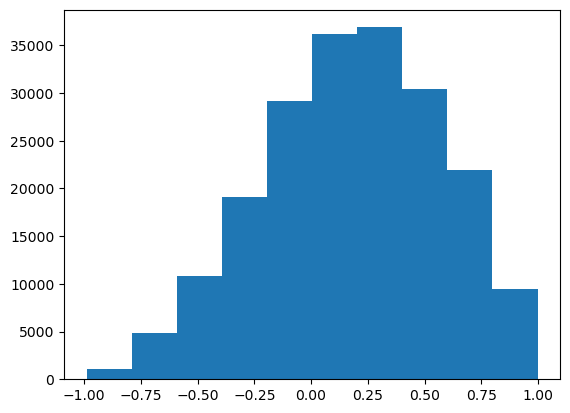

In [18]:
plt.hist(cosine_sim_scores)

In [19]:
numerator = np.sum(np.maximum(-dot, 0.0))
denominator = np.sum(np.abs(dot))

metric = numerator/denominator

print("Fraction of Antagonistic Energy, ", np.round(metric, 4))

Fraction of Antagonistic Energy,  0.1329


In [20]:
total_energy = (ff_tau + pd_tau) * q_vel

numerator = np.abs(ff_power) + np.abs(pd_power) - np.abs(total_energy)
denominator = np.abs(ff_power) + np.abs(pd_power)

cancel_metric = np.mean(numerator) / np.mean(denominator)
print("Internal Power Cancellation - ", np.round(cancel_metric, 4))

Internal Power Cancellation -  0.0778


In [21]:
ratio = np.mean(pd_power_norm) / np.mean(ff_power_norm)
print("Avg. Coupled Torque Ratio - ", np.round(ratio, 4))

Avg. Coupled Torque Ratio -  0.1353


In [22]:
print(np.mean(pd_power_norm))
print(np.mean(ff_power_norm))

3.9458686620951484
29.170464382392893
